In [22]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
print("setup complete")

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

setup complete


checking dataset structure 

In [23]:
import os 

dataset_path="/kaggle/input/datasets/emmarex/plantdisease/PlantVillage"
classes=os.listdir(dataset_path)

new_classes=[]

for c in classes :
    full_path= os.path.join(dataset_path, c)
    if os.path.isdir(full_path):
        new_classes.append(c)

classes = new_classes
print("Number of classes:", len(classes))

Number of classes: 15


In [24]:
print("\nClasses:")
for c in classes:
    print("-", c)


Classes:
- Pepper__bell___Bacterial_spot
- Potato___healthy
- Tomato_Leaf_Mold
- Tomato__Tomato_YellowLeaf__Curl_Virus
- Tomato_Bacterial_spot
- Tomato_Septoria_leaf_spot
- Tomato_healthy
- Tomato_Spider_mites_Two_spotted_spider_mite
- Tomato_Early_blight
- Tomato__Target_Spot
- Pepper__bell___healthy
- Potato___Late_blight
- Tomato_Late_blight
- Potato___Early_blight
- Tomato__Tomato_mosaic_virus


count images per class 

In [25]:
class_image_count={}

for c in classes:
    class_path = os.path.join(dataset_path, c)
    images = os.listdir(class_path)
    images = [img for img in images if img.endswith(('.JPG', '.PNG', '.JPEG'))]
    class_image_count[c] = len(images)

# Display counts
for c, count in class_image_count.items():
    print(f"{c}: {count} images")


Pepper__bell___Bacterial_spot: 997 images
Potato___healthy: 152 images
Tomato_Leaf_Mold: 952 images
Tomato__Tomato_YellowLeaf__Curl_Virus: 3208 images
Tomato_Bacterial_spot: 2127 images
Tomato_Septoria_leaf_spot: 1771 images
Tomato_healthy: 1590 images
Tomato_Spider_mites_Two_spotted_spider_mite: 1676 images
Tomato_Early_blight: 1000 images
Tomato__Target_Spot: 1404 images
Pepper__bell___healthy: 1476 images
Potato___Late_blight: 1000 images
Tomato_Late_blight: 1756 images
Potato___Early_blight: 1000 images
Tomato__Tomato_mosaic_virus: 373 images


plotting Bar plot of no of images per class 

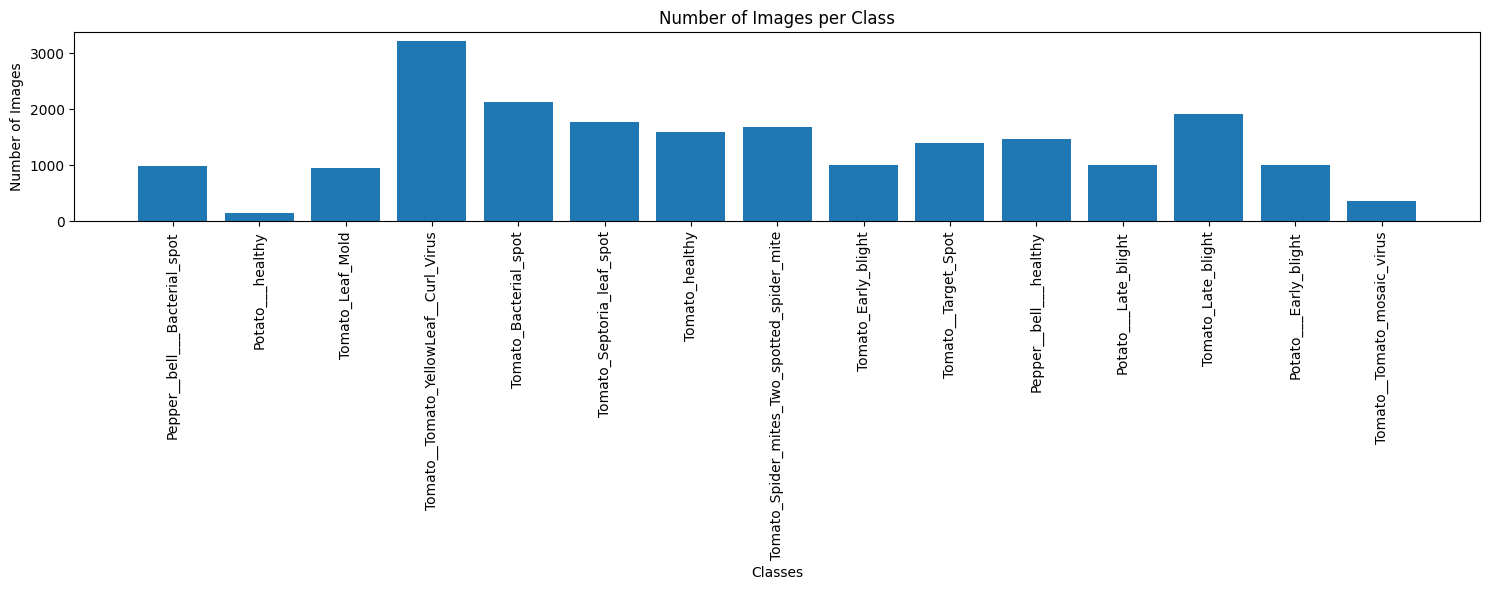

In [26]:
import os
import matplotlib.pyplot as plt

# Dataset path
data_dir = "/kaggle/input/datasets/emmarex/plantdisease/PlantVillage"

class_names = []
image_counts = []

# Count images per class
for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)
    
    if os.path.isdir(class_path):
        count = len(os.listdir(class_path))
        
        class_names.append(class_name)
        image_counts.append(count)

# Plot
plt.figure(figsize=(15,6))
plt.bar(class_names, image_counts)

plt.xticks(rotation=90)
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.title("Number of Images per Class")

plt.tight_layout()
plt.show()

total images in dataset 

In [27]:
total_images = sum(class_image_count.values())
print("\nTotal images in dataset:", total_images)



Total images in dataset: 20482


📦 Load Images Properly

In [28]:
import cv2
import numpy as np

IMG_SIZE = 224

data = []
labels = []

for i, c in enumerate(classes):
    class_path = os.path.join(dataset_path, c)
    
    for img_name in os.listdir(class_path)[:200]:  # limit for speed
        img_path = os.path.join(class_path, img_name)
        
        try:
            img = cv2.imread(img_path)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            
            data.append(img)
            
            # convert to binary label
            if "healthy" in c.lower():
                labels.append(0)
            else:
                labels.append(1)
                
        except:
            pass

X = np.array(data) / 255.0
y = np.array(labels)

print("Data shape:", X.shape)
print("Labels shape:", y.shape)

Data shape: (2952, 224, 224, 3)
Labels shape: (2952,)


dataset structure summary 

In [29]:
print("\nDataset Structure:")
print("PlantVillage/")
for c in classes[:5]:  # show first 5 classes
    print(f" ├── {c}/")
    print(" │    ├── image1.jpg")
    print(" │    ├── image2.jpg")
    print(" │    └── ...")



Dataset Structure:
PlantVillage/
 ├── Pepper__bell___Bacterial_spot/
 │    ├── image1.jpg
 │    ├── image2.jpg
 │    └── ...
 ├── Potato___healthy/
 │    ├── image1.jpg
 │    ├── image2.jpg
 │    └── ...
 ├── Tomato_Leaf_Mold/
 │    ├── image1.jpg
 │    ├── image2.jpg
 │    └── ...
 ├── Tomato__Tomato_YellowLeaf__Curl_Virus/
 │    ├── image1.jpg
 │    ├── image2.jpg
 │    └── ...
 ├── Tomato_Bacterial_spot/
 │    ├── image1.jpg
 │    ├── image2.jpg
 │    └── ...


plotting sample images 

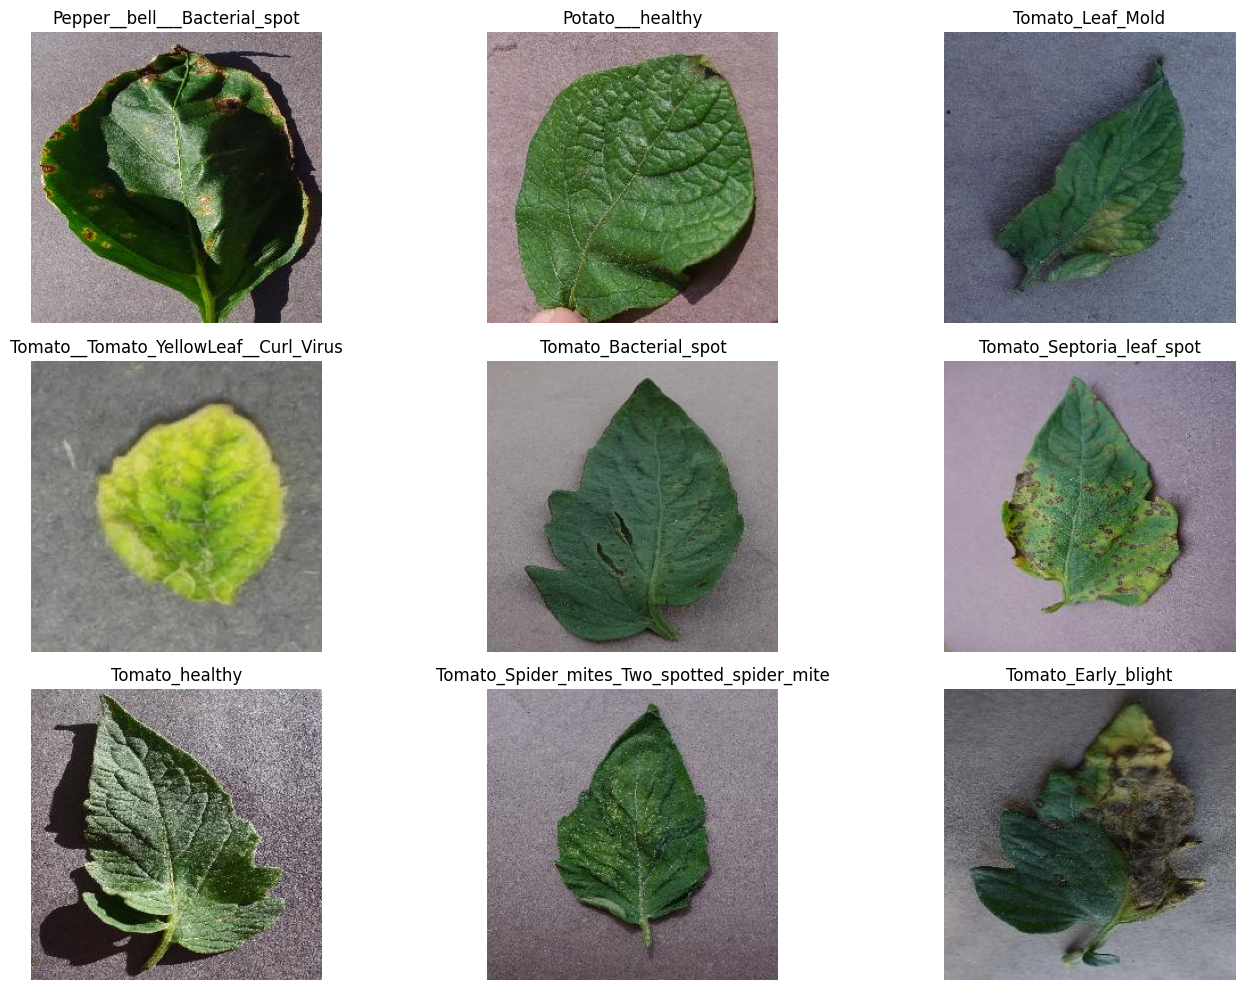

In [30]:
import cv2
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))

for i, c in enumerate(classes[:9]):  # show first 9 classes
    class_path = os.path.join(dataset_path, c)
    img_name = os.listdir(class_path)[0]
    img_path = os.path.join(class_path, img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(c)
    plt.axis("off")

plt.tight_layout()
plt.show()


(A) Data Analysis (EDA)

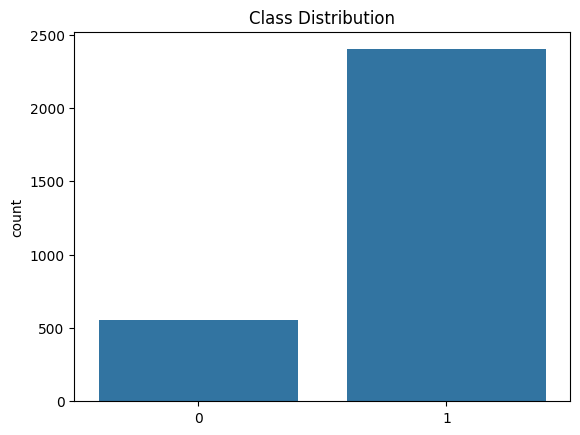

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x=labels)
plt.title("Class Distribution")
plt.show()

In [32]:
import cv2
import os

folder = "/kaggle/input/datasets/emmarex/plantdisease/PlantVillage"

for root, dirs, files in os.walk(folder):
    for file in files:
        if file.lower().endswith((".jpg",".png",".jpeg")):
            path = os.path.join(root, file)

            img = cv2.imread(path)
            if img is None:
                continue

            img = img / 255.0   # ✅ normalization

            # check
            print(img.min(), img.max())
            break
    break

feature Extraction such as colour , texture, shape, spot 

In [33]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt 
from skimage.feature import graycomatrix, graycoprops
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [34]:
data_dir="/kaggle/input/datasets/emmarex/plantdisease/PlantVillage"

In [35]:
def load_image(path):
    img = cv2.imread(path)
    if img is None:
        return None
    img = cv2.resize(img, (224,224))
    return img


colour feature 

In [36]:
feature_names = [
    "Mean_Blue", "Mean_Green", "Mean_Red",
    "Mean_Hue", "Mean_Saturation", "Mean_Value",
    "Contrast", "Homogeneity", "Energy",
    "Area", "Perimeter", "Num_Spots"
]

In [37]:
def extract_color_features(img):
    mean_rgb = np.mean(img, axis=(0,1))
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    mean_hsv = np.mean(hsv, axis=(0,1))
    return np.concatenate([mean_rgb, mean_hsv])

False
Function is working ✅
Mean RGB: [108.48574829 125.63197327 124.46714783]


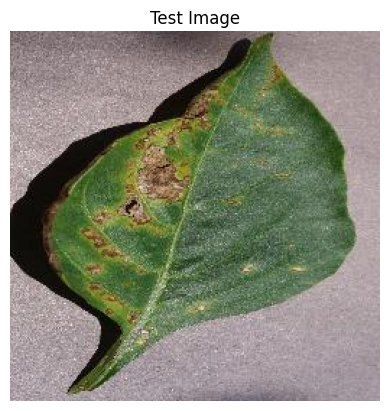

In [38]:
import cv2
import matplotlib.pyplot as plt
%matplotlib inline

img = cv2.imread("/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Pepper__bell___Bacterial_spot/0022d6b7-d47c-4ee2-ae9a-392a53f48647___JR_B.Spot 8964.JPG")  

print(img is None)  # should be False

def analyze_color(img):
    print("Function is working ✅")
    
    mean_rgb = img.mean(axis=(0,1))
    print("Mean RGB:", mean_rgb)

    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Test Image")
    plt.axis('off')
    plt.show()

analyze_color(img)

texture feature 

glcm is gray level co-occurance matrix ....shows how pixel intensities are spatially related in an image.

contrast measures pixel intensity variations...whereas homogeneity measures similarity between pixel values ... energy measures uniformity of texture

correleation is find between neighbouring pixel intensities ..how both intensities are correlated 

In [41]:
from skimage.feature import graycomatrix, graycoprops
import cv2
import numpy as np

img = cv2.imread("/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Pepper__bell___Bacterial_spot/0022d6b7-d47c-4ee2-ae9a-392a53f48647___JR_B.Spot 8964.JPG")

def extract_texture_features(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    glcm = graycomatrix(gray, distances=[1], angles=[0],
                        levels=256, symmetric=True, normed=True)

    contrast = graycoprops(glcm, 'contrast')[0,0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0,0]
    energy = graycoprops(glcm, 'energy')[0,0]
    correlation = graycoprops(glcm, 'correlation')[0,0]

    print("Texture Feature Values:")
    print("Contrast:", contrast)
    print("Homogeneity:", homogeneity)
    print("Energy:", energy)
    print("Correlation:", correlation)

    return np.array([contrast, homogeneity, energy, correlation])


# Call function
features = extract_texture_features(img)

Texture Feature Values:
Contrast: 481.6640931372549
Homogeneity: 0.10751148928274412
Energy: 0.015416354933099417
Correlation: 0.8784625768732464


Image loaded: True


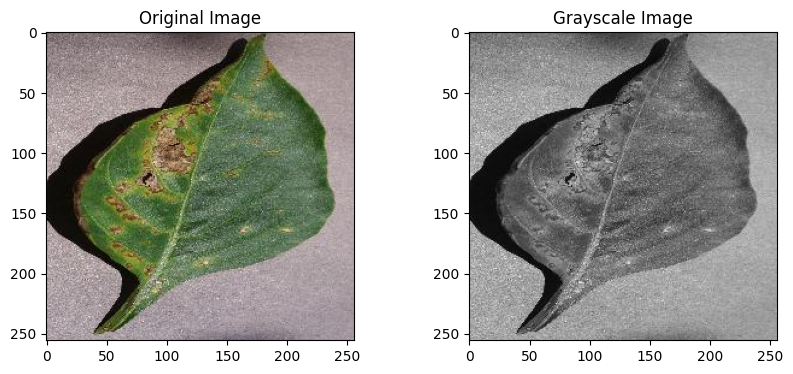

In [40]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Pepper__bell___Bacterial_spot/0022d6b7-d47c-4ee2-ae9a-392a53f48647___JR_B.Spot 8964.JPG")

print("Image loaded:", img is not None)

def visualize_texture_input(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Original Image")

    plt.subplot(1,2,2)
    plt.imshow(gray, cmap='gray')
    plt.title("Grayscale Image")

    plt.show()

# 🔥 CALL FUNCTION
visualize_texture_input(img)

shape features 

Contours = boundary points of white region

thresh (Threshold Image)..it is a binary image ...where 255= white (object) and 0=black(background)

Shape Features:
Number of contours: 774
Area: 26565.5
Perimeter: 3121.049103140831


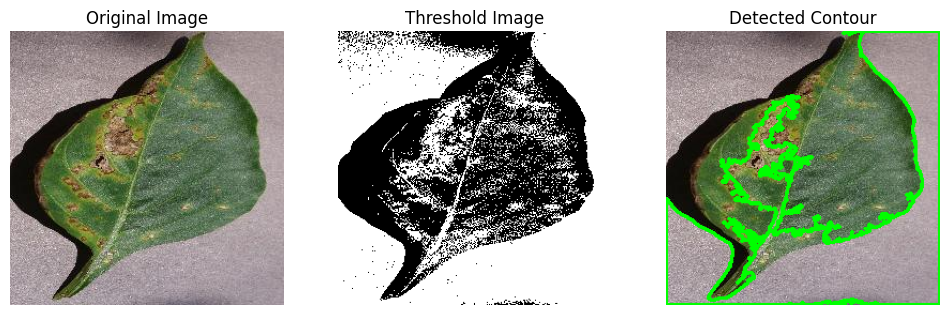

In [43]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

extract_shape_features(img)  

def extract_shape_features(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    _, thresh = cv2.threshold(gray, 0, 255, 
                              cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    contours, _ = cv2.findContours(thresh, 
                                   cv2.RETR_EXTERNAL, 
                                   cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) == 0:
        print("No contours found ❌")
        return np.array([0, 0]), thresh, contours

    #  take largest contour(it represents leaf)
    largest = max(contours, key=cv2.contourArea)

    area = cv2.contourArea(largest)
    perimeter = cv2.arcLength(largest, True)

    # PRINT VALUES
    print("Shape Features:")
    print("Number of contours:", len(contours))
    print("Area:", area)
    print("Perimeter:", perimeter)

    # DRAW CONTOUR
    contour_img = img.copy()
    cv2.drawContours(contour_img, [largest], -1, (0,255,0), 2)

    # VISUALIZATION
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(thresh, cmap='gray')
    plt.title("Threshold Image")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(cv2.cvtColor(contour_img, cv2.COLOR_BGR2RGB))
    plt.title("Detected Contour")
    plt.axis('off')

    plt.show()

    return np.array([area, perimeter]), thresh, contours


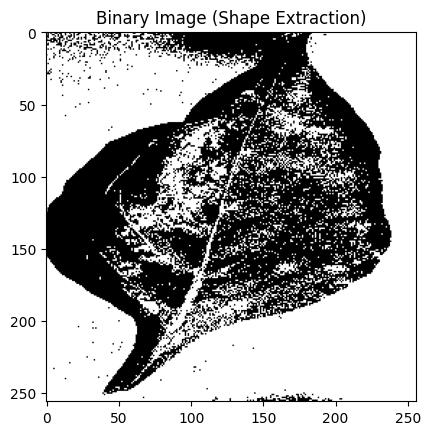

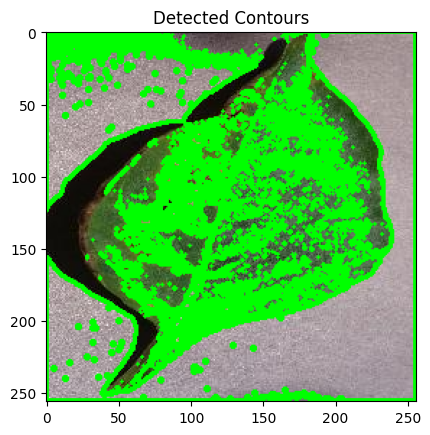

In [31]:
# Binary image
plt.imshow(thresh, cmap='gray')
plt.title("Binary Image (Shape Extraction)")
plt.show()

# Contours draw
img_copy = img.copy()
cv2.drawContours(img_copy, contours, -1, (0,255,0), 2)

plt.imshow(cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB))
plt.title("Detected Contours")
plt.show()

spot feature 

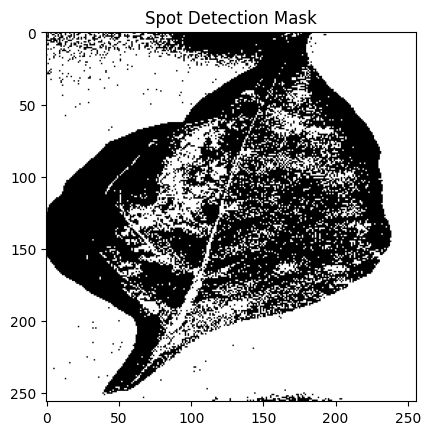

In [32]:
def extract_spot_features(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 100, 255, cv2.THRESH_BINARY_INV)

    contours, _ = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    return np.array([len(contours)])

plt.imshow(thresh, cmap='gray')
plt.title("Spot Detection Mask")
plt.show()

In [48]:
def extract_features(img):
    color = extract_color_features(img)

    texture, _ = extract_texture_features(img)   # FIX
    shape, _, _ = extract_shape_features(img)    # already fixed
    spots = extract_spot_features(img)

    print("color:", np.shape(color))
    print("texture:", np.shape(texture))
    print("shape:", np.shape(shape))
    print("spots:", np.shape(spots))

    return np.concatenate([color, texture, shape, spots])

In [61]:
def extract_features(img):
    color = extract_color_features(img)

    texture = extract_texture_features(img)   # FIXED HERE
    shape, _, _ = extract_shape_features(img)
    spots = extract_spot_features(img)

    return np.hstack([color, texture, shape, spots])

In [62]:
print("Checking folder:", folder)

for file in os.listdir(folder):
    print("File found:", file)

    if file.lower().endswith((".jpg",".png",".jpeg")):
        path = os.path.join(folder, file)
        print("Processing:", path)

        img = load_image(path)

        if img is None:
            print("❌ Image not loaded")
            continue

        features = extract_features(img)

Checking folder: /kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Pepper__bell___Bacterial_spot
File found: 0f72db9c-d635-4415-9781-68937328aed2___NREC_B.Spot 9188.JPG
Processing: /kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Pepper__bell___Bacterial_spot/0f72db9c-d635-4415-9781-68937328aed2___NREC_B.Spot 9188.JPG
File found: 1b8d3e98-43d9-441d-93ef-a359e6e9ddc2___NREC_B.Spot 9052.JPG
Processing: /kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Pepper__bell___Bacterial_spot/1b8d3e98-43d9-441d-93ef-a359e6e9ddc2___NREC_B.Spot 9052.JPG
File found: b6d35d21-4812-4e32-ab9a-b6ddda8cbb79___JR_B.Spot 8972.JPG
Processing: /kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Pepper__bell___Bacterial_spot/b6d35d21-4812-4e32-ab9a-b6ddda8cbb79___JR_B.Spot 8972.JPG
File found: e4e7e5a2-5aa1-4378-833d-9142358c7c9b___JR_B.Spot 9092.JPG
Processing: /kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Pepper__bell___Bacterial_spot/e4e7e5a2-5aa1-4378-833d-9142358c7c9b__

In [63]:
X = []
y = []

print("🚀 Extracting features...")

for label in os.listdir(data_dir):
    folder = os.path.join(data_dir, label)

    if not os.path.isdir(folder):
        continue

    for file in os.listdir(folder):
        if file.lower().endswith((".jpg",".png",".jpeg")):
            path = os.path.join(folder, file)

            img = load_image(path)
            if img is None:
                continue

            features = extract_features(img)

            X.append(features)
            y.append(label)

X = np.array(X)
y = np.array(y)

print("✅ Feature extraction completed!")
print("📊 Feature shape:", X.shape)


🚀 Extracting features...
✅ Feature extraction completed!
📊 Feature shape: (20638, 13)


In [64]:
import pandas as pd

df = pd.DataFrame(X, columns=[
    "R_mean","G_mean","B_mean","R_std","G_std","B_std", 
    "contrast","homogeneity","energy","correlation",   
    "area","perimeter",                               
    "spots"                                             
])

df["label"] = y

print(df.head())

       R_mean      G_mean      B_mean      R_std       G_std       B_std  \
0   75.438178   94.248944   88.414979  88.312301   99.433355   99.432258   
1   98.419244  113.049446  107.793746  80.323880   58.472357  117.111707   
2  113.954281  137.511878  128.015884  66.886619   63.122588  143.809072   
3   96.872290  124.447365  129.158064  85.088289   84.864477  134.156409   
4   52.615294  120.621134  124.582828  68.785176  154.357661  131.046337   

     contrast  homogeneity    energy  correlation  area  perimeter  spots  \
0  285.053011     0.218329  0.027414     0.957501   4.0   9.656854  217.0   
1  285.357964     0.267758  0.041120     0.964834   0.0   0.000000  224.0   
2  150.717989     0.143465  0.020512     0.941709   0.0   0.000000  927.0   
3  222.043462     0.148613  0.022426     0.908657   0.0   0.000000  430.0   
4  214.809978     0.173382  0.018398     0.946887   5.0  12.828427  997.0   

                           label  
0  Pepper__bell___Bacterial_spot  
1  Pepper_

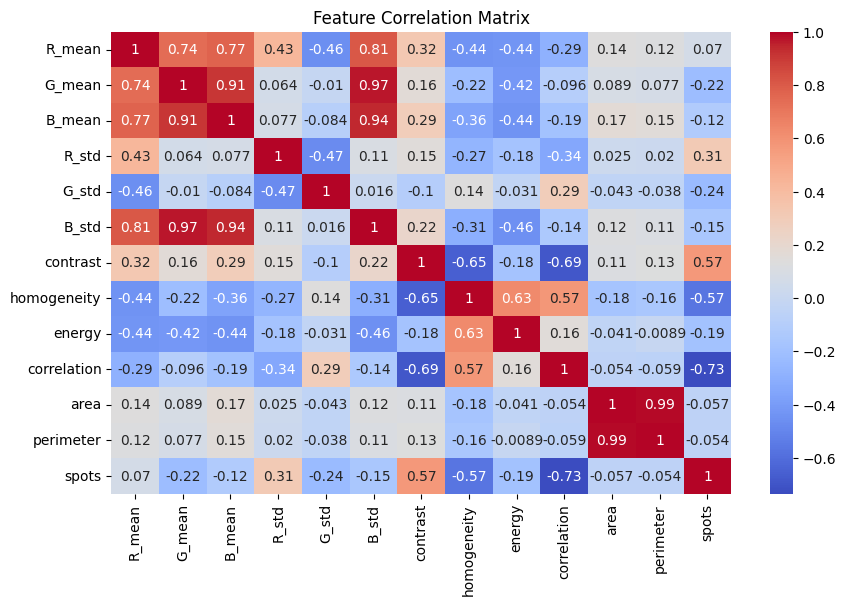

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.drop("label", axis=1).corr(),
            annot=True, cmap="coolwarm")

plt.title("Feature Correlation Matrix")
plt.show()

All color channels are highly correlated

High contrast → low homogeneity

In [82]:
healthy = df[df["label"].str.contains("healthy")].drop("label", axis=1).values.flatten()

unhealthy = df[~df["label"].str.contains("healthy")].drop("label", axis=1).values.flatten()

In [83]:
# Healthy
healthy_mean = np.mean(healthy)
healthy_var = np.var(healthy)

# Unhealthy
unhealthy_mean = np.mean(unhealthy)
unhealthy_var = np.var(unhealthy)

print("Healthy Mean:", healthy_mean)
print("Healthy Variance:", healthy_var)

print("\nUnhealthy Mean:", unhealthy_mean)
print("Unhealthy Variance:", unhealthy_var)

Healthy Mean: 765.6767505467709
Healthy Variance: 29487388.30830125

Unhealthy Mean: 988.4181002416715
Unhealthy Variance: 41983374.85445547


In [70]:
import pandas as pd

df = pd.DataFrame(X)
df["label"] = y

In [77]:
print(df["label"].unique())

['Pepper__bell___Bacterial_spot' 'Potato___healthy' 'Tomato_Leaf_Mold'
 'Tomato__Tomato_YellowLeaf__Curl_Virus' 'Tomato_Bacterial_spot'
 'Tomato_Septoria_leaf_spot' 'Tomato_healthy'
 'Tomato_Spider_mites_Two_spotted_spider_mite' 'Tomato_Early_blight'
 'Tomato__Target_Spot' 'Pepper__bell___healthy' 'Potato___Late_blight'
 'Tomato_Late_blight' 'Potato___Early_blight'
 'Tomato__Tomato_mosaic_virus']


In [78]:
healthy = df[df["label"].str.contains("healthy")].drop("label", axis=1).values.flatten()

unhealthy = df[~df["label"].str.contains("healthy")].drop("label", axis=1).values.flatten()

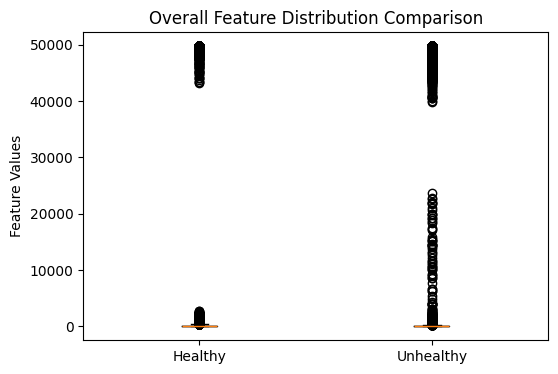

In [80]:
plt.figure(figsize=(6,4))

plt.boxplot([healthy, unhealthy], tick_labels=["Healthy", "Unhealthy"])

plt.title("Overall Feature Distribution Comparison")
plt.ylabel("Feature Values")

plt.show()

Features overlap kar rahe hain, isliye clear separation nahi hai. Outliers aur scale issue ki wajah se performance affect ho sakta hai, so scaling aur better features needed

In [84]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.drop("label", axis=1))

In [85]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = df.drop("label", axis=1)
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier()
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.7955426356589147
